In [1]:
import torch
import pickle
from torch import nn
from tqdm import tqdm
from mydataloader2 import *
from animation_marking import animation_double

In [2]:
class Encoder(nn.Module):
    def __init__(self,input_size,hidden_size,num_layers):
        super().__init__()
    
        self.rnn=nn.LSTM(input_size,hidden_size,num_layers,batch_first=True,dropout=0.1)

    def forward(self,x,state):
        y_hat,new_state =self.rnn(x,state)
        (h,c) = new_state
        return h,c
    
    
class Decoder(nn.Module):
    def __init__(self,input_size,hidden_size,linear_size,output_size,num_layers):
        super().__init__()
        
        self.rnn=nn.LSTM(input_size,hidden_size,num_layers,batch_first=True,dropout=0.1)
        self.linear=nn.Sequential(nn.Dropout(0.1),
            nn.Linear(hidden_size, linear_size), 
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(linear_size, output_size)
        )
        
        self.hidden_size=hidden_size
    
    def forward(self,x,state):
        y_hat,new_state=self.rnn(x,state)
        y_hat=y_hat.squeeze(1)
        y_hat=self.linear(y_hat)

        return y_hat,new_state
    
    
class Seq2Seq(nn.Module):
    
    def __init__(self,input_size,hidden_size,output_size,num_layers,linear_size,pred_steps,train_steps):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.pred_steps=pred_steps
        self.train_steps=train_steps
        self.encoder = Encoder(input_size,hidden_size,num_layers)
        self.decoder = Decoder(input_size, hidden_size,linear_size, output_size, num_layers)

    def forward(self,x,state):
        batch_size = x.shape[0]
        target_len = self.pred_steps
        h,c = self.encoder(x,state)
        outputs = torch.zeros(batch_size,self.pred_steps,self.output_size).to(x.device)
        decoder_input = x[:,-1,:].unsqueeze(1)
        for t in range(target_len):
            decoder_output,(h,c) = self.decoder(decoder_input,(h,c))
            outputs[:,t,:] = decoder_output
            decoder_input = decoder_output.unsqueeze(1)  
            
        h = h.detach()
        c = c.detach()
        return outputs,(h,c)


In [3]:
with open(r"C:\Users\34362\Desktop\LSTM\results\circular.pkl","rb")as f:
    circular=pickle.load(f)
with open(r"C:\Users\34362\Desktop\LSTM\results\infinity_like.pkl","rb")as f:
    infinity_like=pickle.load(f)

In [4]:
batch_size,train_steps,input_size,hidden_size,linear_size,output_size,lr=64,20,3,300,168,3,0.01
pred_steps=12
test_num=10
num_layer=2
scaler = StandardScaler()
scaler.fit(circular)
circular_trans=scaler.transform(circular)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_loder=MyDataLoader(circular_trans,0.8,10,batch_size,train_steps,pred_steps)
net=Seq2Seq(input_size,hidden_size,output_size,num_layer,linear_size,pred_steps,train_steps).to(device)


In [5]:
# net = torch.load("model.pth", map_location=device, weights_only=False)
net.load_state_dict(
    torch.load("time_seq_best.opt", map_location=device, weights_only=False)
)

<All keys matched successfully>

In [6]:
test_loder=data_loder.test_iter(3)
mutil_steps_pred=pred_time_seq(test_loder,net,device,10,train_steps,num_layer,hidden_size,pred_steps)
mutil_steps_pred=scaler.inverse_transform(mutil_steps_pred,train_steps,pred_steps,input_size)
print(mutil_steps_pred[0].shape)

(86, 12, 3)
(20, 12, 3)
(80, 12, 3)
(20, 12, 3)
(85, 12, 3)
(20, 12, 3)
(80, 12, 3)
(20, 12, 3)
(79, 12, 3)
(20, 12, 3)
(137, 12, 3)
(20, 12, 3)
(80, 12, 3)
(20, 12, 3)
(98, 12, 3)
(20, 12, 3)
(149, 12, 3)
(20, 12, 3)
(99, 12, 3)
(20, 12, 3)
(106, 12, 3)


In [7]:
mutil_steps_pred[5][20]

array([[-37.10912486,  -8.09193777,   9.77724207],
       [-37.02690073,  -8.03154631,   9.79150724],
       [-36.66711419,  -8.29314193,   9.84367912],
       [-36.6046665 ,  -8.46027693,   9.86332913],
       [-36.51458455,  -8.58772209,   9.86124672],
       [-36.42902772,  -8.68491513,   9.84478847],
       [-36.35940358,  -8.75767493,   9.81854392],
       [-36.30732216,  -8.81508314,   9.7850017 ],
       [-36.27139324,  -8.86591796,   9.74551866],
       [-36.2488281 ,  -8.91727697,   9.70096853],
       [-36.23661826,  -8.97421155,   9.6520584 ],
       [-36.23197225,  -9.03985804,   9.59945229]])

In [11]:
circular[3278+5][20:42]

,time,tx,ty,tz
20,1.699986e+09,-36.991504,-8.097185,9.699399
21,1.699986e+09,-36.777091,-8.293594,9.775260
22,1.699986e+09,-36.560882,-8.441696,9.831011
23,1.699986e+09,-36.323924,-8.554458,9.872236
24,1.699986e+09,-36.084605,-8.617348,9.895795
25,1.699986e+09,-35.829942,-8.639403,9.910849
26,1.699986e+09,-35.579737,-8.624170,9.911345
27,1.699986e+09,-35.327755,-8.566529,9.904113
28,1.699986e+09,-35.079541,-8.470066,9.892291
29,1.699986e+09,-34.832827,-8.338042,9.872693


总帧数: 106


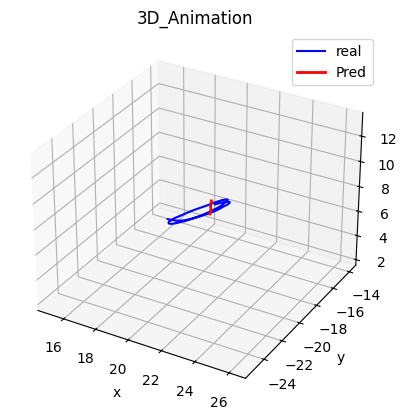

总帧数: 100


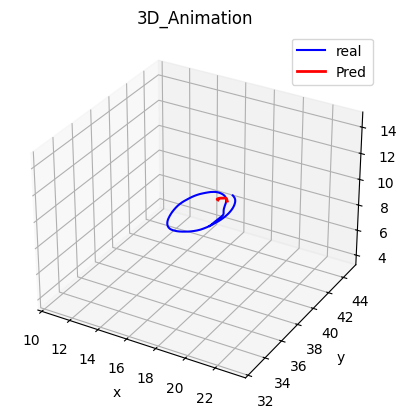

总帧数: 105


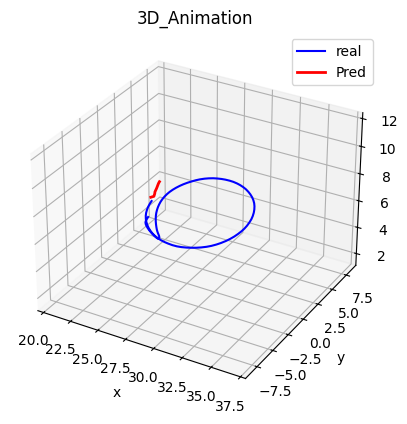

总帧数: 100


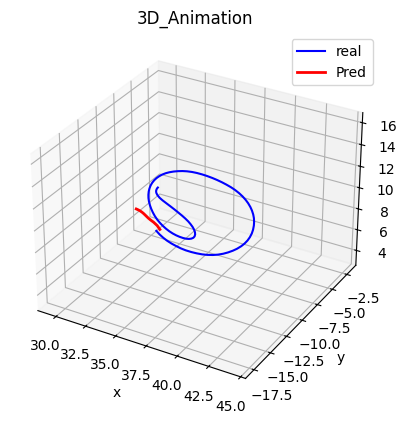

总帧数: 99


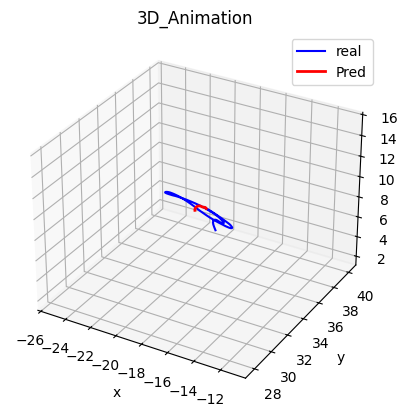

总帧数: 157


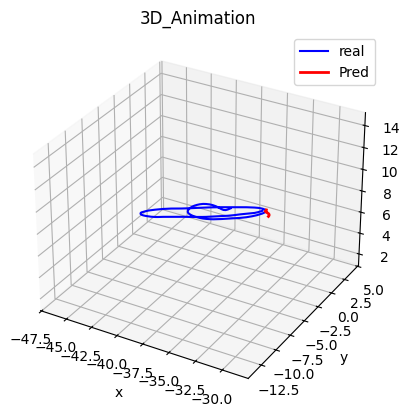

总帧数: 100


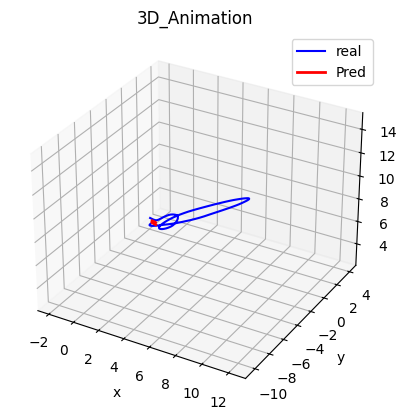

总帧数: 118


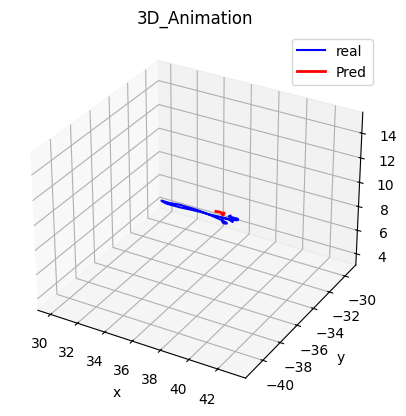

总帧数: 169


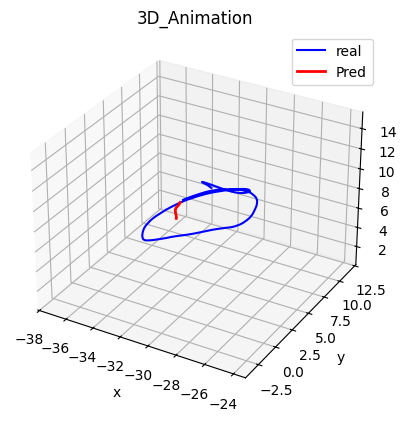

总帧数: 119


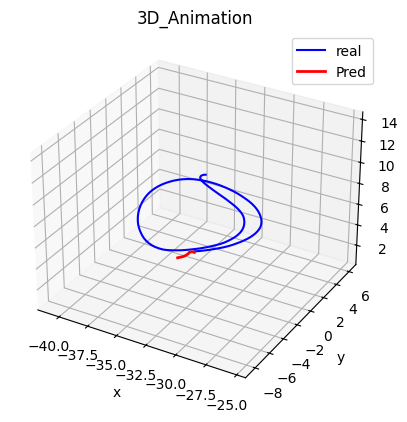

In [8]:
test_start_idx = len(circular) - test_num
for i in range(test_num):
    dataset1=circular[i+test_start_idx]
    dataset2=mutil_steps_pred[i]
    animation_double(i,dataset1,dataset2)